# Recreating EVON Figure 3 — and where H-EVON differs

Figure 3 of the EVON paper (Minut et al., 2026, arXiv:2606.23357) studies a **binary
Bayesian logistic regression** on USPS 3-vs-5 (16x16 images -> 256 weights). The
weight is kept as a **16x16 matrix `W`**, so EVON learns a *structured* (Kronecker)
256x256 posterior covariance, while IVON is restricted to a diagonal one. The paper
shows EVON recovers the **exact full-Gaussian** posterior (covariance and variational
objective), whereas IVON converges to a worse bound.

We reproduce both panels and add the **H-EVON** (mode + Hutchinson) variant to probe
why its posterior samples were poor on the MLP notebook. Logistic regression is
log-concave and *near-Gaussian*, so the Hessian at the mode (what Hutchinson measures)
should be the right posterior precision here. If H-EVON still misbehaves on this
problem it points beyond the intrinsic mode-vs-expected-Hessian issue; if it behaves
well, the MLP failure is specific to flat/over-parameterized minima.

All methods are compared on the **same** objective
`F(m, Sigma) = ess * E_q[mean-NLL] + KL( N(m,Sigma) || N(0, (1/(ess*delta)) I) )`,
with `ess = N` and `delta = 0.01/N` (Table 3), i.e. an isotropic prior `Sigma0 = 100 I`.

In [1]:
import os, urllib.request

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
import seaborn as sns

from blrax import ivon, evon, noisy_value_and_grad, sample_posterior, get_scale
from blrax.states import MatrixEvonLeaf, DiagEvonLeaf, _is_evon_leaf

sns.set_theme(context="notebook", style="white", color_codes=True)
print("devices:", jax.devices())

devices: [CudaDevice(id=0), CudaDevice(id=1)]


## Data — USPS 3-vs-5, 16x16

N=1540  pos_frac=0.535  ess=1540  delta=1.62e-04  prior_var=4.0


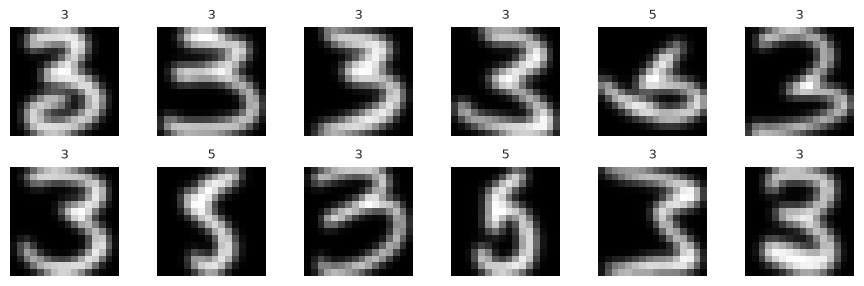

In [2]:
USPS_ARFF_URL = "https://openml.org/data/v1/download/19329737/USPS.arff"


def load_usps_3v5(cache_dir="data"):
    """USPS 3-vs-5 as (N,16,16) images in [-1,1] and binary labels (1==digit 3).

    Downloads the OpenML USPS ARFF once over HTTPS (valid certificate chain).
    """
    os.makedirs(cache_dir, exist_ok=True)
    path = os.path.join(cache_dir, "USPS.arff")
    if not os.path.exists(path):
        req = urllib.request.Request(USPS_ARFF_URL, headers={"User-Agent": "urllib"})
        with open(path, "wb") as f:
            f.write(urllib.request.urlopen(req).read())
    rows, in_data = [], False
    for line in open(path).read().splitlines():
        s = line.strip()
        if not in_data:
            in_data = s.lower() == "@data"
            continue
        if s and not s.startswith("%"):
            rows.append(s)
    arr = np.array([[float(t) for t in r.split(",")] for r in rows], np.float32)
    labels = arr[:, 0].astype(int)
    X = arr[:, 1:]                                  # (N,256) in [-1,1]
    mask = (labels == 4) | (labels == 6)            # digits 3 and 5 (1-indexed)
    Xb = X[mask].reshape(-1, 16, 16)
    yb = (labels[mask] == 4).astype(np.int32)       # 1 == digit 3
    return jnp.asarray(Xb), jnp.asarray(yb)


X, y = load_usps_3v5()
N = int(X.shape[0]); ess = float(N); delta = 0.25 / N; prior_var = 1.0 / (ess * delta)
print(f"N={N}  pos_frac={float(y.mean()):.3f}  ess={ess:.0f}  delta={delta:.2e}  prior_var={prior_var:.1f}")

fig, axes = plt.subplots(2, 6, figsize=(9, 3))
for ax, i in zip(axes.ravel(), np.random.default_rng(0).choice(N, 12, replace=False)):
    ax.imshow(np.asarray(X[i]), cmap="gray"); ax.set_title("3" if int(y[i]) == 1 else "5", fontsize=9)
    ax.axis("off")
fig.tight_layout()

## Model & shared variational objective

Logistic regression with a 16x16 weight matrix: `logit(x) = sum(W * x) + b`. The shared
objective `F` (used to train the full-Gaussian reference and to score every method)
samples `theta ~ N(m, Sigma)` for the expected NLL and adds the analytic Gaussian KL.
We flatten `theta` as `[vec_F(W), b]` (column-major `W`) to match the `(Q_R kron Q_L)`
convention used for EVON's covariance below.

In [3]:
def logits_fn(params, X):
    return jnp.sum(params["W"][None] * X, axis=(1, 2)) + params["b"]


def loss_fn(params, X, y, key=None):
    lg = logits_fn(params, X)
    return optax.sigmoid_binary_cross_entropy(lg, y.astype(lg.dtype)).mean()


def params_to_theta(params):
    return jnp.concatenate([params["W"].reshape(-1, order="F"), jnp.atleast_1d(params["b"])])


def theta_to_params(theta):
    return {"W": theta[:256].reshape(16, 16, order="F"), "b": theta[256]}


def gaussian_kl(m, Sigma, prior_var):
    k = m.shape[0]
    _, logdet = jnp.linalg.slogdet(Sigma)
    return 0.5 * (jnp.trace(Sigma) / prior_var + (m @ m) / prior_var - k
                  + k * jnp.log(prior_var) - logdet)


def eval_objective(m, Sigma, X, y, key, ess, prior_var, n_samples=256):
    k = m.shape[0]
    L = jnp.linalg.cholesky(Sigma + 1e-9 * jnp.eye(k))
    thetas = m[None] + jax.random.normal(key, (n_samples, k)) @ L.T
    exp_nll = jnp.mean(jax.vmap(lambda th: loss_fn(theta_to_params(th), X, y))(thetas))
    return ess * exp_nll + gaussian_kl(m, Sigma, prior_var)

## EVON covariance materialization

EVON's structured posterior is `q(W) = N(M, (Q_R kron Q_L) diag(vec V) (Q_R kron Q_L)^T)`
with `V = 1/(ess (H + delta))`. We materialize the dense 256x256 covariance of `vec_F(W)`
and assemble a 257x257 block covariance (W block + scalar b). IVON's is diagonal.

In [4]:
def evon_full_cov(leaf, ess, delta):
    """Dense 256x256 covariance of vec(W) (column-major) for a MatrixEvonLeaf."""
    V = 1.0 / (ess * (leaf.H + delta))            # (16,16)
    Q = jnp.kron(leaf.QR, leaf.QL)                # (256,256)
    d = V.reshape(-1, order="F")                  # vec(V), column-major
    return (Q * d[None, :]) @ Q.T


def posterior_cov(state, params, ess, delta):
    """(m, Sigma) with the 256x256 W block + scalar b block (EVON state)."""
    m = params_to_theta(params)
    leaves = jax.tree.leaves(state.leaves, is_leaf=_is_evon_leaf)
    wl = next(l for l in leaves if l.H.ndim == 2)
    bl = next(l for l in leaves if l.H.ndim != 2)
    SigW = (evon_full_cov(wl, ess, delta) if isinstance(wl, MatrixEvonLeaf)
            else jnp.diag((1.0 / (ess * (wl.H + delta))).reshape(-1, order="F")))
    Sigma = jnp.zeros((257, 257)).at[:256, :256].set(SigW)
    Sigma = Sigma.at[256, 256].set(1.0 / (ess * (jnp.ravel(bl.H)[0] + delta)))
    return m, Sigma


def ivon_cov(state, params, ess, delta):
    """(m, Sigma) diagonal, from an IVON state via get_scale."""
    m = params_to_theta(params)
    sc = get_scale(state)
    var = jnp.concatenate([(sc["W"] ** 2).reshape(-1, order="F"), jnp.atleast_1d(sc["b"] ** 2)])
    return m, jnp.diag(var)

## Full-Gaussian VI reference

The "exact" reference: the optimal `N(m, Sigma)` over **all** full covariances, found by
optimizing the **same** `F` over a Cholesky factor with Adam (reparameterization trick,
analytic KL). The Adam learning rate / step count are convergence details, not Table 3.

In [5]:
def train_full_gaussian_vi(X, y, ess, delta, key, lr=1e-2, steps=30000, n_mc=128):
    """Optimal full-covariance Gaussian under the shared objective F. Returns (m,Sigma,trace)."""
    k = 257
    prior_var = 1 / (ess * delta)
    p = {"m": jnp.zeros(k), "L": jnp.eye(k) * jnp.sqrt(prior_var)}
    opt = optax.adam(lr); st = opt.init(p)

    def objective(p, key):
        L = jnp.tril(p["L"])
        thetas = p["m"][None] + jax.random.normal(key, (n_mc, k)) @ L.T
        exp_nll = jnp.mean(jax.vmap(lambda th: loss_fn(theta_to_params(th), X, y))(thetas))
        return ess * exp_nll + gaussian_kl(p["m"], L @ L.T, prior_var)

    @jax.jit
    def step(p, st, key):
        loss, g = jax.value_and_grad(objective)(p, key)
        u, st = opt.update(g, st, p)
        return optax.apply_updates(p, u), st, loss

    trace = []
    for t in range(steps):
        key, kk = jax.random.split(key)
        p, st, loss = step(p, st, kk)
        trace.append(float(loss))
    L = jnp.tril(p["L"])
    return p["m"], L @ L.T, jnp.array(trace)


m_ref, Sigma_ref, trace_ref = train_full_gaussian_vi(X, y, ess, delta, jr.PRNGKey(0), lr=0.002)
F_ref = float(jnp.mean(trace_ref[-50:]))
print(f"full-Gaussian VI reference: F = {F_ref:.1f}")

full-Gaussian VI reference: F = 202.9


## Train IVON / EVON / H-EVON (paper Table 3)

`ess = N`, `delta = 0.01/N`, `lr = 1`, `clip_radius = 0.1`, `b1 = 0.9`. EVON/H-EVON:
`hess_init = 0.1`, `b2 = 0.999`. IVON: `hess_init = 0.05`, `b2 = 0.9995`. H-EVON adds
`hess_every = 1` (re-estimate the Hessian every step, so the diagnostic isn't confounded
by gating staleness). Full-batch updates.

In [6]:
def train_method(kind, X, y, ess, delta, key, lr=1.0, hess_init=0.1,
                 steps=4000, record_every=50, **opt_kw):
    """Full-batch train an IVON/EVON/H-EVON method, recording F at checkpoints."""
    params = {"W": jnp.zeros((16, 16)), "b": jnp.array(0.0)}
    estimator = "hutchinson" if kind == "h-evon" else "sampling"
    opt = (ivon if kind == "ivon" else evon)(lr, ess=ess, hess_init=hess_init,
                                             weight_decay=delta, **opt_kw)
    st = opt.init(params)
    prior_var = 1.0 / (ess * delta)
    cov_of = ivon_cov if kind == "ivon" else posterior_cov

    @jax.jit
    def train_step(params, st, key):
        _, g, st = noisy_value_and_grad(loss_fn, st, params, key, X, y, estimator=estimator)
        u, st = opt.update(g, st, params)
        return optax.apply_updates(params, u), st

    steps_rec, F_rec = [], []
    for t in range(steps):
        key, ks, ko = jax.random.split(key, 3)
        params, st = train_step(params, st, ks)
        if t % record_every == 0 or t == steps - 1:
            m, Sig = cov_of(st[0], params, ess, delta)
            steps_rec.append(t); F_rec.append(float(eval_objective(m, Sig, X, y, ko, ess, prior_var)))
    m, Sigma = cov_of(st[0], params, ess, delta)
    return dict(m=m, Sigma=Sigma, trace_steps=jnp.array(steps_rec),
                trace_F=jnp.array(F_rec), state=st, params=params)

CFG = {"ivon":   dict(hess_init=0.05, b2=0.9995, clip_radius=0.1),
       "evon":   dict(hess_init=0.1,  b2=0.999,  clip_radius=0.1, hess_clip_ratio=1e4),
       "h-evon": dict(hess_init=0.1,  b2=0.995,  clip_radius=0.1, hess_clip_ratio=1e4)}
res = {}
for kind, cfg in CFG.items():
    res[kind] = train_method(kind, X, y, ess, delta, jr.PRNGKey(1), steps=30_000, lr=1.0, **cfg)
    F = float(jnp.mean(res[kind]["trace_F"][-5:]))
    mv = float(jnp.median(jnp.diag(res[kind]["Sigma"])[:256]))
    print(f"{kind:7s} F={F:.1f}   median marginal var={mv:.4f}")
print(f"{'VI ref':7s} F={F_ref:.1f}")

# convention guard: EVON's materialized cov diagonal must match get_scale
_wl = next(l for l in jax.tree.leaves(res["evon"]["state"][0].leaves, is_leaf=_is_evon_leaf) if l.H.ndim == 2)
_sc = get_scale(res["evon"]["state"][0])["W"]
assert jnp.allclose(jnp.diag(evon_full_cov(_wl, ess, delta)),
                    (_sc ** 2).reshape(-1, order="F"), rtol=3e-3, atol=1e-6)

ivon    F=1322.1   median marginal var=0.3296
evon    F=261.6   median marginal var=2.4809
h-evon  F=380.9   median marginal var=0.7365
VI ref  F=202.9


## Covariance matrices (left panel of Fig. 3)

The 256x256 `W`-block covariance for each method, shared color scale. EVON recovers the
full Gaussian's off-diagonal structure; IVON is diagonal by construction.

Text(0.5, 0.98, 'Posterior covariance of the 256 weights')

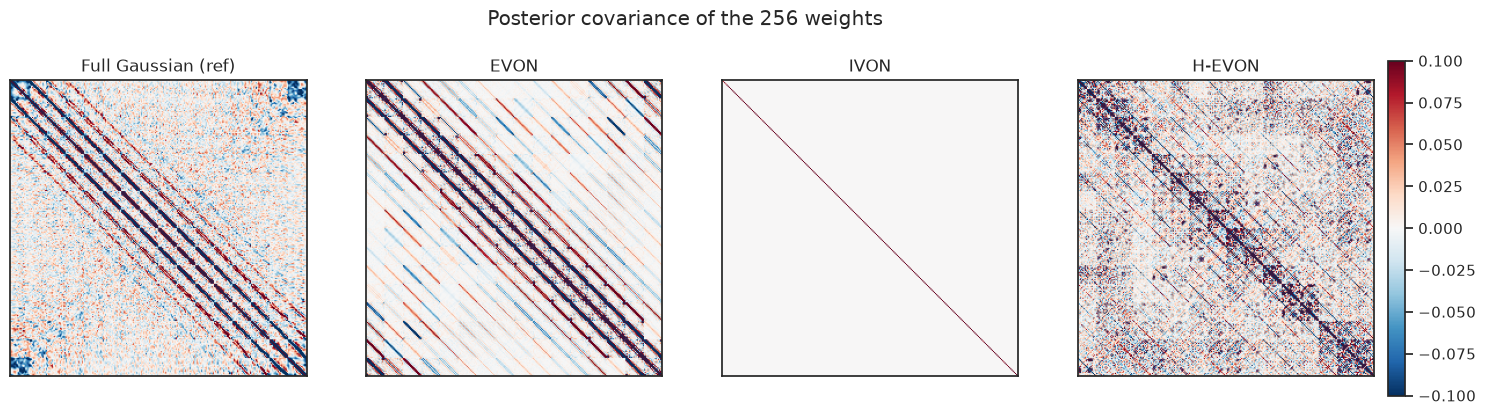

In [7]:
def W_block(S): return np.asarray(S[:256, :256])

mats = {"Full Gaussian (ref)": W_block(Sigma_ref),
        "EVON": W_block(res["evon"]["Sigma"]),
        "IVON": W_block(res["ivon"]["Sigma"]),
        "H-EVON": W_block(res["h-evon"]["Sigma"])}
vmax = 0.1
vmin = -vmax
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, M) in zip(axes, mats.items()):
    im = ax.imshow(M, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.012, pad=0.01)
fig.suptitle("Posterior covariance of the 256 weights")

## Variational objective convergence (right panel of Fig. 3)

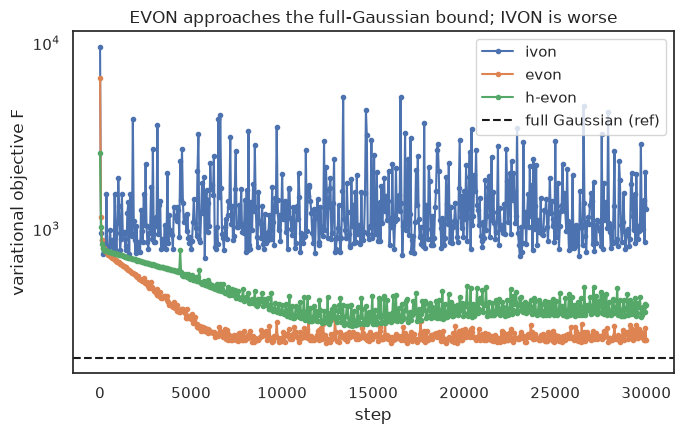

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for kind, c in [("ivon", "C0"), ("evon", "C1"), ("h-evon", "C2")]:
    ax.plot(np.asarray(res[kind]["trace_steps"]), np.asarray(res[kind]["trace_F"]),
            "o-", ms=3, color=c, label=kind)
ax.axhline(F_ref, color="k", ls="--", label="full Gaussian (ref)")
ax.set_xlabel("step"); ax.set_ylabel("variational objective F"); ax.set_yscale("log")
ax.legend(); ax.set_title("EVON approaches the full-Gaussian bound; IVON is worse")
fig.tight_layout()

## Where H-EVON goes wrong — and where it doesn't

Left: each method's per-weight marginal variance vs the full-Gaussian reference (y=x is
perfect). Right: `Sigma_W(H-EVON) - Sigma_W(full Gaussian)`. On this **well-conditioned,
log-concave** problem the mode Hessian is the correct posterior precision, so H-EVON
tracks the reference closely — unlike the over-parameterized MLP, where the mode Hessian
collapses in flat directions and the posterior over-disperses. That localizes the MLP
sampling failure to the flat-minimum regime rather than an implementation bug.

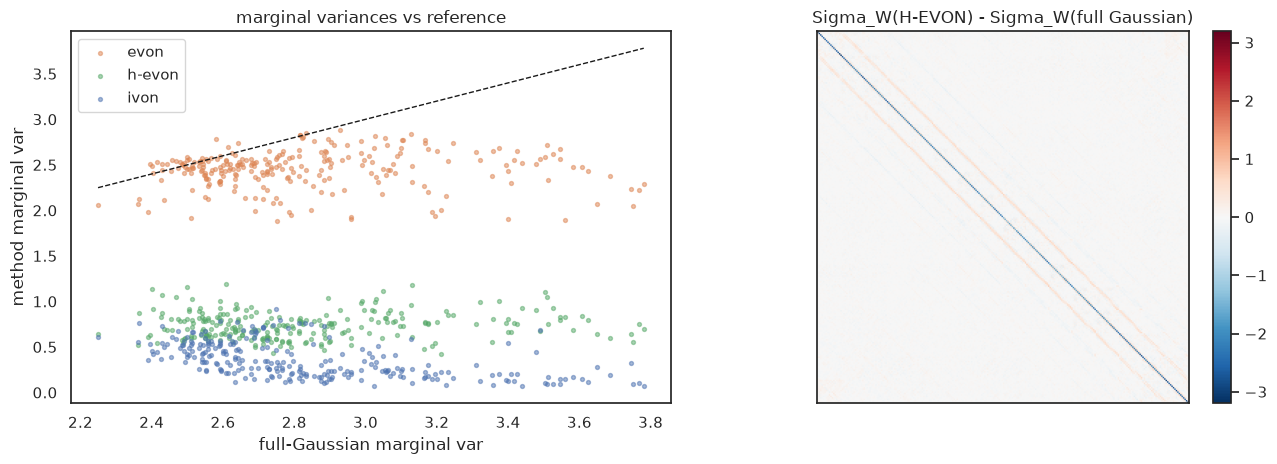

In [9]:
ref_d = np.diag(W_block(Sigma_ref))
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.8))
for kind, c in [("evon", "C1"), ("h-evon", "C2"), ("ivon", "C0")]:
    a0.scatter(ref_d, np.diag(W_block(res[kind]["Sigma"])), s=8, alpha=0.5, color=c, label=kind)
lo, hi = ref_d.min(), ref_d.max()
a0.plot([lo, hi], [lo, hi], "k--", lw=1); a0.set_xlabel("full-Gaussian marginal var")
a0.set_ylabel("method marginal var"); a0.legend(); a0.set_title("marginal variances vs reference")

diff = W_block(res["h-evon"]["Sigma"]) - W_block(Sigma_ref)
v = np.abs(diff).max()
im = a1.imshow(diff, cmap="RdBu_r", vmin=-v, vmax=v); a1.set_xticks([]); a1.set_yticks([])
a1.set_title("Sigma_W(H-EVON) - Sigma_W(full Gaussian)")
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04)
fig.tight_layout()